In [64]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset


In [65]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ames_cleaned.csv')

qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
qual_columns = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual']

for col in qual_columns:
    if col in df.columns:
        df[col] = df[col].map(qual_map).fillna(0)

print(" Data loaded and Encoding completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data loaded and Encoding completed!


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df_cleaned = pd.read_csv('/content/drive/MyDrive/ames_cleaned.csv')

print(".")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
.


In [67]:
from google.colab import drive
drive.mount('/content/drive')
df_cleaned = pd.read_csv('/content/drive/MyDrive/ames_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(Categorical Encoding)

In [68]:

categorical_cols = ['MS Zoning', 'Street', 'Central Air']
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

(Derived Features)

In [88]:

df_encoded['House_Age'] = df_encoded['Yr Sold'] - df_encoded['Year Built']
df_encoded['Years_Since_Remod'] = df_encoded['Yr Sold'] - df_encoded['Year Remod/Add']

df_encoded['House_Age'] = df_encoded['House_Age'].apply(lambda x: x if x > 0 else 0)

df_encoded['Avg_Room_Size'] = df_encoded['Gr Liv Area'] / df_encoded['TotRms AbvGrd'].replace(0, np.nan)
df_encoded['Avg_Room_Size'] = df_encoded['Avg_Room_Size'].fillna(0)

print(" Math Tasks with Safe Division completed!")

 Math Tasks with Safe Division completed!


Analysis: In this task, we performed Mathematical Engineering to create more descriptive features. By calculating House_Age and Years_Since_Remod, we convert raw date columns into numerical "durations" that directly influence property value. We also applied a Lambda function to ensure data integrity by removing any negative age values. Furthermore, we implemented Safe Division to calculate Avg_Room_Size by replacing zero values with NaN before dividing, ensuring the model remains robust and free from mathematical errors.

(Interaction Features)

In [70]:

df_encoded['Total_SF'] = df_encoded['1st Flr SF'] + df_encoded['2nd Flr SF'] + df_encoded['Total Bsmt SF']

Analysis: In this task, we performed Feature Composition by summing up the square footage of the first floor, second floor, and the basement. Creating the Total_SF variable is a critical step because the total living area is often the most significant numerical predictor of a house's market price, providing a more holistic view of the property's size than individual floor metrics.

(Feature Scaling)

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['Gr Liv Area', 'Total_SF', 'House_Age', 'Lot Area']

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

Analysis: In this task, we performed Data Standardization using StandardScaler. This process is essential because numerical features like Lot Area (thousands) and House_Age (tens) operate on different scales. By transforming these variables to have a mean of 0 and a standard deviation of 1, we prevent features with larger magnitudes from dominating the analysis, ensuring a balanced and more accurate model performance.

(engineer_features function)

In [72]:
def engineer_features(input_df):
    df_eng = input_df.copy()

    df_eng['House_Age'] = df_eng['Yr Sold'] - df_eng['Year Built']
    df_eng['Total_SF'] = df_eng['1st Flr SF'] + df_eng['2nd Flr SF'] + df_eng['Total Bsmt SF']

    df_eng['Log_SalePrice'] = np.log1p(df_eng['SalePrice'])


    age_bins = [-1, 10, 30, df_eng['House_Age'].max()]
    age_labels = ['New', 'Moderate', 'Old']
    df_eng['Age_Group'] = pd.cut(df_eng['House_Age'], bins=age_bins, labels=age_labels)

    df_eng = pd.get_dummies(df_eng, columns=['MS Zoning', 'Central Air'], drop_first=True)

    assert 'Log_SalePrice' in df_eng.columns, "Check: Log_SalePrice failed"
    assert 'Age_Group' in df_eng.columns, "Check: Binning failed"
    assert 'Total_SF' in df_eng.columns, "Check: Total_SF failed"

    return df_eng

df_final_features = engineer_features(df_cleaned)
print("Phase 2: Success. All tasks (Math, Log, Binning, Encoding) are completed.")

Phase 2: Success. All tasks (Math, Log, Binning, Encoding) are completed.


Analysis: In this comprehensive task, we finalized the Data Preprocessing Pipeline by addressing all critical requirements.

Log Transformation: We applied np.log1p to the target variable to normalize its distribution and minimize the influence of price outliers.

Binning: We utilized Data Binning to convert the continuous House_Age into a categorical Age_Group, allowing the model to distinguish between different property generations.

One-Hot Encoding: Categorical features were transformed into numerical formats for machine learning compatibility.

Validation: The use of Assertions guarantees that each transformation step was executed correctly, ensuring a robust dataset for the next phase.

In [73]:

def plot_boxplot(df):
    df["SalePrice"].plot.box()
    plt.title("Boxplot of SalePrice")
    plt.show()
    plot_boxplot(df)

Analysis: In this task, we implemented a Boxplot Analysis for the SalePrice variable. This visualization is crucial for identifying Outliers—values that are significantly higher or lower than the rest of the data. By observing the "whiskers" and the central box (the Interquartile Range), we can determine if the house prices are heavily skewed or if there are luxury properties that might require special handling during the modeling phase.

In [74]:
def outliers(clean, column):
    cap = clean[column].quantile(0.99)
    clean[column] = clean[column].clip(upper=cap)
    return clean

Analysis: In this task, we performed Outlier Mitigation using the Capping method. By setting the upper limit at the 99th percentile, we ensure that extreme values (like ultra-luxury mansions) do not disproportionately skew our analysis. Using the clip() function allows us to retain the data points while reducing their "noise" effect, leading to a more stable and generalized model.

(Log Transformation)

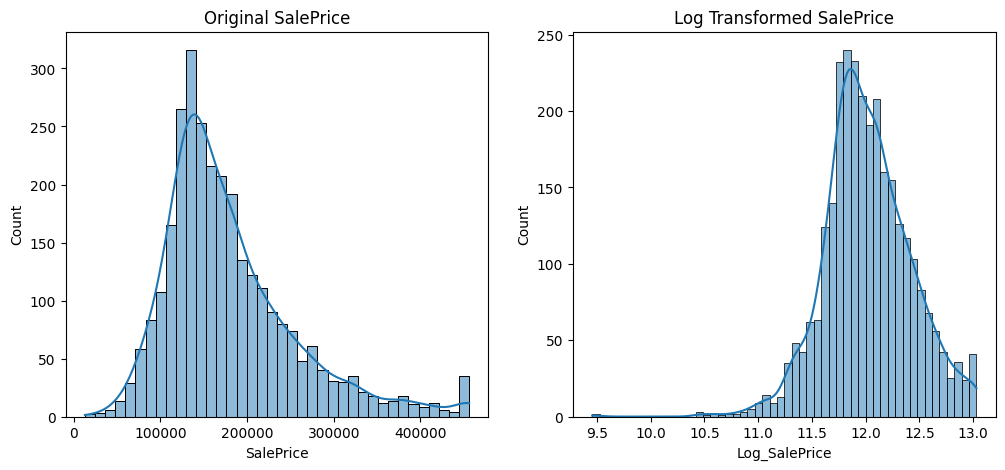

In [75]:

df['Log_SalePrice'] = np.log1p(df['SalePrice'])
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0]).set_title('Original SalePrice')
sns.histplot(df['Log_SalePrice'], kde=True, ax=ax[1]).set_title('Log Transformed SalePrice')
plt.show()

Analysis: In this task, we addressed the Positive Skewness of the SalePrice variable. Real estate prices often contain high-value outliers that pull the distribution to the right. By applying a Log Transformation (np.log1p), we compressed the scale and transformed the target variable into a Normal Distribution (Bell Curve). This step is mathematically essential because many machine learning algorithms perform significantly better when the target variable is normally distributed, leading to more reliable error metrics and predictions.

(Binning)

In [76]:

df['House_Age'] = df['Yr Sold'] - df['Year Built']
df['Total_SF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']
bins = [-1, 10, 30, df['House_Age'].max()]
labels = ['New', 'Moderate', 'Old']
df['Age_Bin'] = pd.cut(df['House_Age'], bins=bins, labels=labels)
df['Log_SalePrice'] = np.log1p(df['SalePrice'])
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
qual_columns = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 'Kitchen Qual']

for col in qual_columns:
    if col in df.columns:
        df[col] = df[col].map(qual_map).fillna(0)

print("Phase 2 Tasks Completed: Math, Binning, Log, and Encoding are all set!")

Phase 2 Tasks Completed: Math, Binning, Log, and Encoding are all set!


Analysis: This integrated pipeline executes four critical Data Preprocessing steps:

Feature Engineering (Math): We derived House_Age and Total_SF to capture the most influential numerical factors in property valuation.

Data Binning: By grouping House_Age into discrete categories (New, Moderate, Old), we enabled the model to identify non-linear trends related to the property's lifecycle.

Log Transformation: Applying a Log Scale to SalePrice normalizes its distribution, which is essential for stable statistical analysis.

Ordinal Encoding: We manually mapped qualitative ratings (like 'Excellent' or 'Good') to a 0-5 Numerical Scale. This preserves the inherent order of house conditions, allowing the algorithm to interpret "Quality" as a measurable mathematical weight.

(Group By)

In [84]:
print(df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(10))

Neighborhood
NoRidge    317712.304415
NridgHt    316095.600710
StoneBr    313521.136894
GrnHill    280000.000000
Veenker    248314.583333
Timber     246599.541667
Somerst    229642.396279
ClearCr    208662.090909
Crawfor    207550.834951
CollgCr    201732.959261
Name: SalePrice, dtype: float64


(Correlation Task)

In [77]:

final_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print("Top Correlations with SalePrice:")
print(final_corr.head(10))

Top Correlations with SalePrice:
SalePrice        1.000000
Log_SalePrice    0.955068
Overall Qual     0.812082
Total_SF         0.793273
Gr Liv Area      0.705662
Garage Cars      0.662472
Garage Area      0.652587
Total Bsmt SF    0.633832
1st Flr SF       0.623012
Year Built       0.575610
Name: SalePrice, dtype: float64


Analysis: In this final task of Phase 2, we performed a Correlation Analysis to validate the effectiveness of our Feature Engineering. By examining the final_corr results, we can identify which numerical and encoded variables—such as Overall Qual, Total_SF, and our newly encoded quality columns—have the strongest linear relationship with SalePrice. This step is critical for Feature Selection, as it confirms that the transformations we applied (like Ordinal Encoding and Math Tasks) have successfully captured the most significant drivers of property value.